# Earth-like planet transit for PlatoSim3 paper

In [2]:
# Reload code outside notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

In [3]:
import os
import h5py
import scipy
import wotan
import numpy as np
import pandas as pd
from tqdm import tqdm

from matplotlib import pyplot as plt
import matplotlib.colors  as colors
import matplotlib.patches as patches

from astropy.io import fits
from astropy import units as u
from astropy.coordinates import SkyCoord

from scipy.signal import periodogram
from scipy.ndimage import median_filter
from scipy.interpolate import interp2d

# PlatoSim
import platosim.referenceFrames as rf
import platosim.plot            as pt
import platosim.utilities       as ut
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

## Fetch simulation

In [101]:
fdir = 'simulations_PlatoSimPaper2023/hareAndHound'
idir = f'{os.getcwd()}/{fdir}'
odir = os.getcwd()

In [102]:
# Download all files from KUL FTP
ut.downloadFromFTP(fdir, odir, server='platodata')

TimeoutError: [Errno 110] Connection timed out

In [12]:
# Load all data into a lightcurve object
lcs = LightCurve(idir, mode="multi")

In [116]:
# Unzip all compressed files
lcs.unpack()

In [13]:
# Fetch all feather filenames
filenames = lcs.files('ftr')

['/lhome/nicholas/data/platosimPaper/SunEarth_TranGranPuls/detrended/000000001_Ncam1.1_Q1.ftr',
 '/lhome/nicholas/data/platosimPaper/SunEarth_TranGranPuls/detrended/000000001_Ncam1.1_Q2.ftr',
 '/lhome/nicholas/data/platosimPaper/SunEarth_TranGranPuls/detrended/000000001_Ncam1.1_Q3.ftr',
 '/lhome/nicholas/data/platosimPaper/SunEarth_TranGranPuls/detrended/000000001_Ncam1.1_Q4.ftr',
 '/lhome/nicholas/data/platosimPaper/SunEarth_TranGranPuls/detrended/000000001_Ncam1.1_Q5.ftr',
 '/lhome/nicholas/data/platosimPaper/SunEarth_TranGranPuls/detrended/000000001_Ncam1.1_Q6.ftr',
 '/lhome/nicholas/data/platosimPaper/SunEarth_TranGranPuls/detrended/000000001_Ncam1.1_Q7.ftr',
 '/lhome/nicholas/data/platosimPaper/SunEarth_TranGranPuls/detrended/000000001_Ncam1.1_Q8.ftr',
 '/lhome/nicholas/data/platosimPaper/SunEarth_TranGranPuls/detrended/000000001_Ncam1.1_Q9.ftr',
 '/lhome/nicholas/data/platosimPaper/SunEarth_TranGranPuls/detrended/000000001_Ncam1.1_Q10.ftr',
 '/lhome/nicholas/data/platosimPaper/Su

## Test detrending for a single star, camera, and quarter

In [14]:
# Calculate the PLATO passband magnitude of G2V star
ut.passbandConversionV2P(10, 5777, inverse=True)

10.394306041803523

In [15]:
# Check filename
filename  = filenames[0]
filename

'/lhome/nicholas/data/platosimPaper/SunEarth_TranGranPuls/detrended/000000001_Ncam1.1_Q1.ftr'

In [18]:
# Fetch the first light curve for this star
lc = LightCurve(lcs.files("ftr")[0])

In [20]:
# Show the data product
lc.data().head()

,time,flux,flux_err,flux_trend,flux_detrend,flux_clip,bg,bg_err,cx,cx_err,cy,cy_err
0,18.75,405806.493034,169.840371,406205.807878,-983.035783,-983.035783,1998.231968,12.647739,2.874434,0.001015,3.164027,0.000985
1,43.75,405385.305088,169.796495,406205.396594,-2018.908444,-2018.908444,2024.426389,12.681930,2.873054,0.001013,3.164201,0.000987
2,68.75,405914.532061,169.891259,406204.987189,-715.045696,-715.045696,2023.415495,12.680592,2.877098,0.001018,3.165001,0.000986
3,93.75,407050.367577,170.087374,406204.767959,2081.707761,2081.707761,2005.917199,12.659862,2.879893,0.001020,3.160027,0.000983
4,118.75,404604.670541,169.662539,406204.810457,-3939.244131,-3939.244131,2021.047882,12.679649,2.878025,0.001021,3.161638,0.000986


### Information about variability

In [17]:
# Show the noise-less lightv curve used
lc_var = lc.varsource()
lc_var.head()

,time,gran,puls,tran,occu,beam,elli,comb,spot
0,0.0,-30.227651,3.786619,0.0,0.0,0.000187,-2.756385e-07,-26.441032,0.0
1,25.0,-26.257797,6.413521,0.0,0.0,0.000187,-2.756395e-07,-19.844276,0.0
2,50.0,-11.255772,7.667452,0.0,0.0,0.000187,-2.756405e-07,-3.588321,0.0
3,75.0,-5.799542,7.407067,0.0,0.0,0.000187,-2.756414e-07,1.607525,0.0
4,100.0,-2.566221,5.239296,0.0,0.0,0.000187,-2.756424e-07,2.673075,0.0


<IPython.core.display.Javascript object>


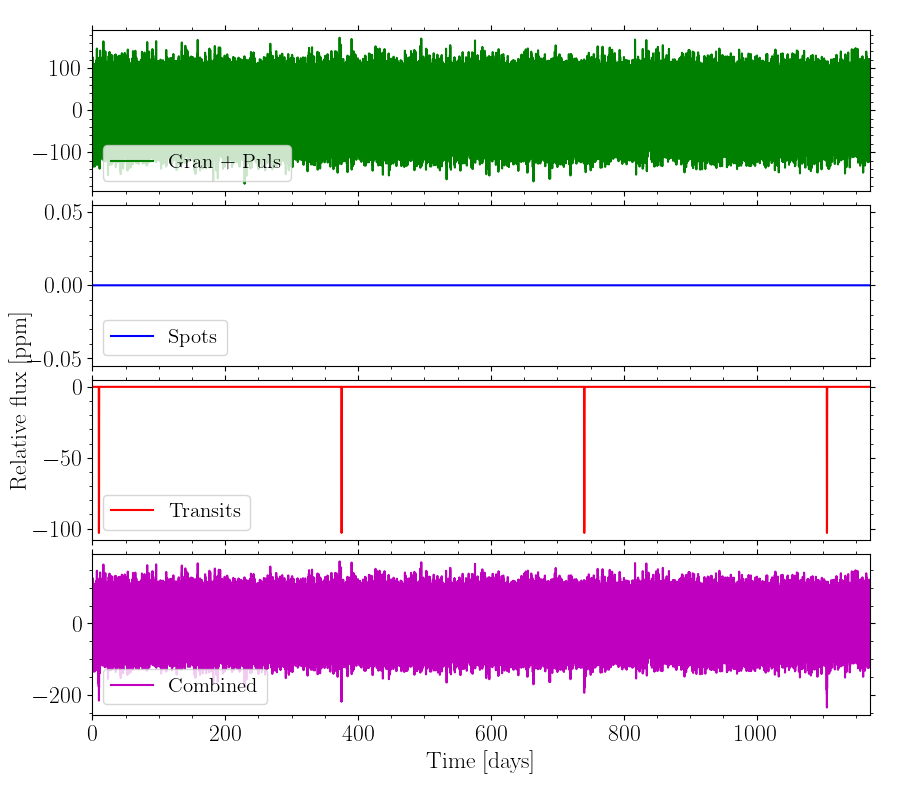

In [153]:
# Plot the input noise-less light curve
fig, ax = lc.plot_varsource();

### Detrending with **Wotan**

The software Wotan is implemented into the detrending module of the `LightCurve` class. We use the robust fitting method cosine description. Note that the detrending works best if you in priori known the full transit time of the planet (i.e. from contact point 1 to 4). We here calculate this period and use is a `window_lenght` detrend criteria:

In [139]:
P = 365.25
t0 = 10
tdur = wotan.t14(R_s=1, M_s=1, P=P, small_planet=True)
print(f'Transit duration : {tdur*24:.2f} hours')

Transit duration : 12.97 hours


<IPython.core.display.Javascript object>


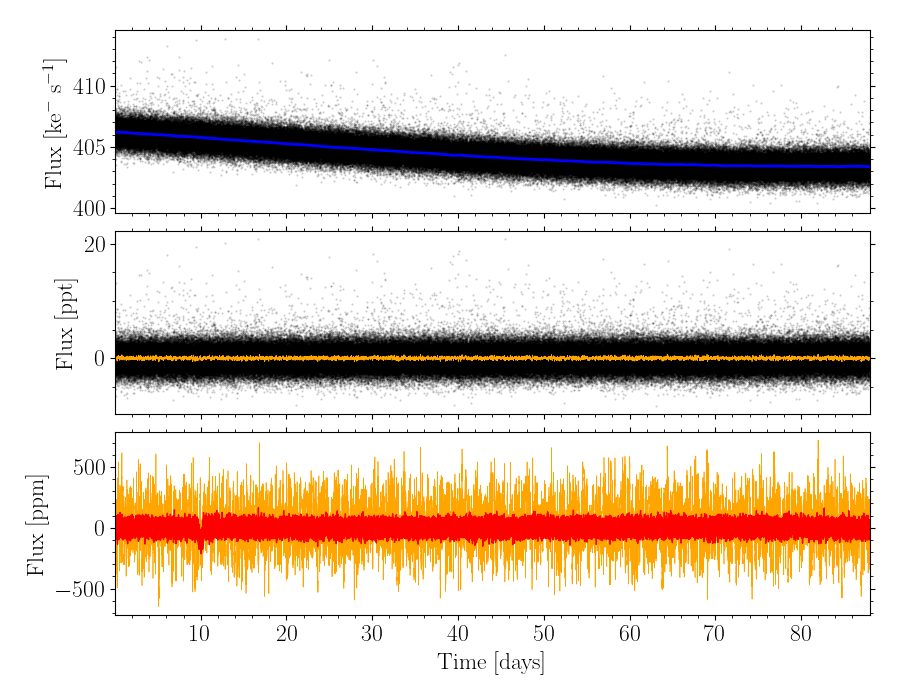

In [140]:
df = lc.detrend(model="wotan", window=3*tdur, mask=[P, tdur, t0], plot=True)

### Outlier rejection after detrending

<IPython.core.display.Javascript object>


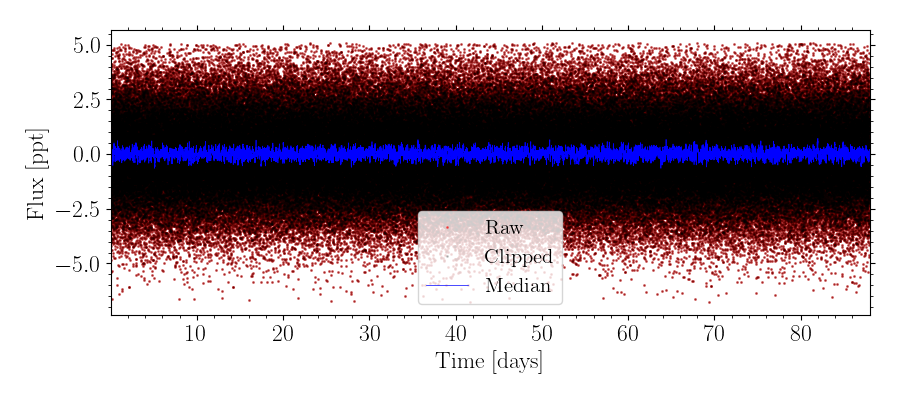

In [144]:
df = lc.clip(model='sigma', window=3*tdur, low=4, high=5, plot=True)

---
## Earth-like transit
---

In [16]:
# Load all data for a single star
idir = "/lhome/nicholas/data/platosimPaper/SunEarth_TranGranPuls"
lcs = LightCurve(idir+'/detrended', mode="multi")

In [17]:
# Get noise-less light curve
lc = LightCurve(lcs.files('ftr')[0])
df_var  = lc.varsource()

# Get parameter used in input model
varinfo = lc.varsource_info()
P    = varinfo.P_day[0]
t0   = varinfo.t0_day[0]
tdur = wotan.t14(R_s=1, M_s=1, P=P, small_planet=True)
print(f'Transit duration : {tdur*24:.2f} hours')

Transit duration : 12.97 hours


### Detrend all observations and merge them into a single light curve

In [ ]:
# # Merge all data across cameras and quarter
# ofile = f'{idir}/../lc_final_tot.ftr'
# lc = lcs.merge(ofile=ofile, flux_group_mean=True)

In [19]:
# Laod the merged detrended light curves
ofile = f'{idir}/lc_final_tot.ftr'
lc = LightCurve(ofile)
df = lc.data()
df

,time,flux
0,100.000072,1.000468
1,100.000145,0.999469
2,100.000217,1.000834
3,100.000289,1.000135
4,100.000362,1.000509
...,...,...
14400463,1167.999349,0.999709
14400464,1167.999566,1.000300
14400465,1167.999638,1.001882
14400466,1167.999855,1.000405


In [ ]:
# Shorten and save
# tmax = df.time.iloc[-1]/day
# df_short = df[df.time < tmax*day]

# Select specific times span
# df_short = df[df.time < 1000*day]
df_short = df[(df.time > 100*day) & (df.time < 1200*day)]

In [ ]:
# Remove bad detrended data
df_short = df_short.drop(df_short[(df_short.time > 338*day) & (df_short.time < 341*day)].index)

In [ ]:
# Define parameters
time = df_short.time/day
flux = df_short.flux_detrend
time_var = df_var.time/day
flux_var = df_var.comb
flux_tra = df_var.tran

In [ ]:
# Compute PSD for Prime data
freq_gran, psd_gran = periodogram(df_var.gran, 1/25, scaling='density')
freq_puls, psd_puls = periodogram(df_var.puls, 1/25, scaling='density')
freq_tran, psd_tran = periodogram(df_var.tran, 1/25, scaling='density')
freq_gran *= 1e6  # [muHz]
freq_puls *= 1e6  # [muHz]
freq_tran *= 1e6  # [muHz]

In [ ]:
freq_sim, psd_sim = periodogram(flux, 1/25, scaling='density')
freq_sim *= 1e6  # [muHz]

In [ ]:
# Creaet plot
fig, ax = plt.subplots(2, 1, figsize=(9,8))
# Plot global model
ax[0].plot(freq_gran, psd_gran, "-", c='royalblue', lw=0.3, label="Granulation")
ax[0].plot(freq_puls, psd_puls, "-", c='orange', lw=0.3, label="Pulsations")
ax[0].set_xlim(1e2, np.max(freq_gran))
ax[0].set_ylim(1e0, 1e8)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel(r"Frequency, $\nu$ [$\mu$Hz]")
ax[0].set_ylabel(r"PSD [ppm$^2$ $\mu$Hz$^{-1}$]")
ax[0].legend(ncol=1, loc='upper right', fontsize=16)
# Plot global model
ax[1].plot(freq_puls, psd_gran+psd_puls, "-", c='k', lw=0.3, label="Stochastic oscillations")
ax[1].set_xlim(2600, 3600)
ax[1].set_ylim(1e5, 0.5e8)
# ax[1].set_xticks([2.5e3, 3.0e3, 3.5e3, 4.0e3])
# ax[1].set_xticklabels(['2500','3000','3500','4000'])
# ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel(r"Frequency, $\nu$ [$\mu$Hz]")
ax[1].set_ylabel(r"PSD [ppm$^2$ $\mu$Hz$^{-1}$]")
ax[1].legend(ncol=1, loc='upper right', fontsize=16)
# ax.plot(f_red, psd, "r-", label="1 min median")
plt.tight_layout()

# Save figure
fig.savefig('oscillations.png', bbox_inches='tight', dpi=200)

In [ ]:
# Mask transits using Wotan
mask = wotan.transit_mask(time=time, period=P, duration=tdur, T0=t0)

In [ ]:
# Resample (bin) data using scipy
from scipy.stats import binned_statistic
flux_bin, time_bin, nbin = binned_statistic(time, flux, statistic='median', bins=int(tmax*24))
time_bin = time_bin[:-1] + np.diff(time_bin)[0]/2.
# tim_short = df_short.drop(df_short[(df_short.time > 338*day) & (df_short.time < 341*day)].index)

In [ ]:
# Remove extreme outliers
time_bin = time_bin[(flux_bin > -200) & (flux_bin < 200)]
flux_bin = flux_bin[(flux_bin > -200) & (flux_bin < 200)]

In [ ]:
# Plot the corrected timeseries
plt.figure(figsize=(9,4))
plt.plot(time_bin, flux_bin, '.', c='deeppink', ms=10,  alpha=1.0, mec='k', label='1h bins');
# plt.plot(time_var, flux_tra, '-', c='orange',   lw=2,   alpha=1.0, label='TLS fit')

In [ ]:
# Plot the corrected timeseries
fig, ax = plt.subplots(1, 1, figsize=(8,3))
ax.plot(time,       flux,       ',', c='k', ms=1.0, alpha=0.01)
ax.plot(time[mask], flux[mask], ',', c='deeppink', ms=1.0, alpha=1)
# Labels
ax.set_xlabel(r"Time [days]")
ax.set_ylabel(r"Relative flux [ppm]")
# Settings
ax.set_xlim(np.min(time), np.max(time))
ax.set_ylim(-5000, 5000)
plt.tight_layout(pad=0.0)

In [ ]:
# Save an light curve to perform TLS from a script: time [days], flux [mean to 1]
df_tot = pd.DataFrame({'time': time.to_numpy(), 'flux': flux.to_numpy()/1e6+1})
df_bin = pd.DataFrame({'time': time_bin,        'flux': flux_bin/1e6+1})
df_tot.to_feather(f'{idir}/lc_final_tot.ftr')
df_bin.to_feather(f'{idir}/lc_final_bin.ftr')
df_bin.to_csv(f'{idir}/lc_final_tot.csv')

In [ ]:
# Perform TLS vetting
# model   = tls.transitleastsquares(time.to_numpy(), flux.to_numpy()/1e6+1)
model   = tls.transitleastsquares(time_bin, flux_bin/1e6+1)
results = model.power(R_star=1.0,
                      R_star_min=0.13,
                      R_star_max=2.50,
                      M_star=1.0,
                      M_star_min=0.1,
                      M_star_max=1.2,
                      period_min=10.0, 
                      period_max=400.0,
                      n_transits_min=2,
                      use_threads=10);

print('Period', format(results.period, '.5f'), 'd')
print(len(results.transit_times), 'transit times in time series:', \
        ['{0:0.5f}'.format(i) for i in results.transit_times])
print('Transit depth', format(results.depth, '.5f'))
print('Best duration (days)', format(results.duration, '.5f'))
print('Signal detection efficiency (SDE):', results.SDE)
# Store result
phase_res = results.model_folded_phase
flux_res  = (results.model_folded_model-1)*1e6

# Plot SDE
plt.figure(figsize=(9,4))
ax = plt.gca()
ax.axvline(results.period, alpha=0.4, lw=3)
plt.xlim(np.min(results.periods), np.max(results.periods))
for n in range(2, 10):
    ax.axvline(n*results.period,   alpha=0.4, lw=1, linestyle="dashed")
    ax.axvline(results.period / n, alpha=0.4, lw=1, linestyle="dashed")
plt.ylabel(r'SDE')
plt.xlabel('Period (days)')
plt.plot(results.periods, results.power, color='black', lw=0.5)
plt.xlim(0, max(results.periods))
plt.tight_layout();

In [ ]:
results.snr

In [ ]:
# Prepare for phase plot
from PyAstronomy import pyasl
from scipy.stats import binned_statistic
# For data
phase = pyasl.foldAt(time, P, T0=t0+P/2)
sort  = np.argsort(phase)
# For variable
phase_var = pyasl.foldAt(time_var, P, T0=t0+P/2)
sort_var  = np.argsort(phase_var)
# Binned data
phase_bin = pyasl.foldAt(time_bin, P, T0=t0+P/2)
sort_bin  = np.argsort(phase_bin)

### Final plot for paper

In [ ]:
# Create overview plot of transit vetting
fig, ax0 = lcs.plot_multi(group=1, camera=1, quarter=False, figsize=(9,11))
ax0.set_ylim(93, 103)
# Plot transit times for ax 0 and 1
ymax = 0.73
transit_times = np.arange(t0, 4*P, P)
for T in transit_times:
    ymax -= 0.10 
    ax0.axvline(x=T, ymax=ymax, c='deeppink', linestyle='--', lw=1.3)
    if T == transit_times[-1]:
        ax0.axvline(x=T, ymax=ymax, c='deeppink', linestyle='--', lw=1.3, label='Transit times')
#     ax1.axvline(x=T, ymax=0.1,  c='deeppink', linestyle='--', lw=1.3)
ax0.legend(loc='upper right', ncols=2, fontsize=15, frameon=True)
    
# Plot the corrected timeseries
ax1 = fig.add_subplot(312)
ax1.plot(time,       flux/1e3,       ',', c='k', ms=1.0, alpha=0.01)
ax1.plot(time[mask], flux[mask]/1e3, '.', c='deeppink', ms=0.1, alpha=1, label='In-transit data')
# Labels
ax1.set_xlabel(r"Time [days]")
ax1.set_ylabel(r"Relative flux [ppt]")
# Settings
leg1 = ax1.legend(loc='upper right', ncols=1, fontsize=15, frameon=True)
# leg1.legendHandles[0]._legmarker.set_alpha(1)
leg1.legendHandles[0].set_markersize(5)
ax1.set_xlim(np.min(time), np.max(time))
ax1.set_ylim(-5, 5)

# Plot the corrected timeseries
ax2 = fig.add_subplot(313)
ax2.plot(phase_var[sort_var], flux_var[sort_var], '-', c='royalblue',   lw=0.5, alpha=1.0, label='Input model')
ax2.plot(phase_bin[sort_bin], flux_bin[sort_bin], '.', c='deeppink', ms=10,  alpha=1.0, mec='k', label='1h bins')
# ax2.plot(phase_var[sort_var], flux_tra[sort_var], '-', c='w', lw=5)
ax2.plot(phase_res, flux_res, '-', c='orange', lw=3, label='TLS fit')
# Labels
ax2.set_xlabel(r"Orbital phase")
ax2.set_ylabel(r"Relative flux [ppm]")
ax2.legend(loc='upper right', ncols=3, fontsize=15, frameon=True)
# Settings
ax2.set_xlim(0.496, 0.504)
ax2.set_ylim(-250, 250)
# ax2.set_ylim(-2000, 1000)

# Save the figure
plt.tight_layout(w_pad=0.5)
fig.savefig('transit.png', bbox_inches='tight', dpi=200);    